In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42

/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/

In [2]:
h21 = sc.read_h5ad("/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Yuanyuan/BG_cellbender/bg_astro/HMBA_human_Astro_21clusters_withCellBenderLayerUMAP_aibs_epoch50.h5ad")
h21

AnnData object with n_obs × n_vars = 136684 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac

In [3]:
drop_clusters = ["Human-232", "Human-143"] #mixed

mask = ~h21.obs["Cluster"].isin(drop_clusters)
h19 = h21[mask].copy()

print("Remaining cells:", h19.n_obs)
print(h19.obs["cluster"].value_counts())

Remaining cells: 134124
cluster
h-14     58596
h-160    17037
h-485    12908
h-472    12864
h-159    12053
h-31      3350
h-149     2649
h-452     2522
h-231     1998
h-7       1893
h-145     1783
h-450     1643
h-28      1492
h-150     1359
h-152     1322
h-479      243
h-146      172
h-227      162
h-230       78
Name: count, dtype: int64


In [4]:
h19.obs["subGroup"] = pd.Categorical(h19.obs["subGroup"], categories=["GM STR", "GM exSTR", "WM"], ordered=True)

In [5]:
#h19 = sc.read_h5ad("/data/BG_ASC_revision_dataset_input2/HMBA_human_Astro_3subGroups.h5ad")
h19

AnnData object with n_obs × n_vars = 134124 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac

In [6]:
X = h19.layers['cellbender_counts']

rows = np.random.choice(X.shape[0], 1000, replace=False)
cols = np.random.choice(X.shape[1], 1000, replace=False)

sub = X[rows][:, cols].toarray()
print(np.allclose(sub, np.round(sub)))
print(sub.max())

True
214


### 1.1  downsample

In [7]:
pd.crosstab(h19.obs['subGroup'], h19.obs['donor_id'])


donor_id,H18.30.001,H19.30.004,H20.30.001,H20.30.002,H21.30.004,H23.30.001,H24.30.001,H24.30.003,H24.30.004,H24.30.007
subGroup,,,,,,,,,,
GM STR,2003,2,5380,3708,8040,5813,11356,10737,9353,7447
GM exSTR,2905,692,5560,2541,4993,3024,5062,7302,4121,4340
WM,2002,443,1774,1935,3105,4924,2431,1648,8989,2494


In [8]:
def downsample_adata(
    adata,
    group_key,
    donor_key,
    max_cells=1000,
    min_cells=10,
    random_state=123,
    verbose=True
):
    
    rng = np.random.default_rng(random_state)
    keep_indices = []
    
    dropped = 0
    kept = 0

    for donor in sorted(adata.obs[donor_key].unique()):
        adata_donor = adata[adata.obs[donor_key] == donor]
        
        for grp in sorted(adata_donor.obs[group_key].unique()):
            idx = adata_donor.obs[group_key] == grp
            cells = adata_donor.obs[idx].index.values
            
            # filter very low-coverage
            if len(cells) < min_cells:
                dropped += 1
                continue
            
            # downsample
            if len(cells) > max_cells:
                sampled = rng.choice(cells, max_cells, replace=False)
            else:
                sampled = cells
            
            keep_indices.extend(sampled)
            kept += 1

    if verbose:
        print(f"[Downsample] kept groups: {kept}, dropped groups (<{min_cells} cells): {dropped}")
        print(f"[Downsample] total cells kept: {len(keep_indices)}")

    return adata[keep_indices].copy()


In [9]:
h19_subgroup_ds = downsample_adata(
    h19,
    group_key="subGroup",
    donor_key="donor_id",
    max_cells=1000,
    min_cells=10
)


[Downsample] kept groups: 29, dropped groups (<10 cells): 1
[Downsample] total cells kept: 28135


In [10]:
pd.crosstab(h19_subgroup_ds.obs['subGroup'], h19_subgroup_ds.obs['donor_id'])


donor_id,H18.30.001,H19.30.004,H20.30.001,H20.30.002,H21.30.004,H23.30.001,H24.30.001,H24.30.003,H24.30.004,H24.30.007
subGroup,,,,,,,,,,
GM STR,1000,0,1000,1000,1000,1000,1000,1000,1000,1000
GM exSTR,1000,692,1000,1000,1000,1000,1000,1000,1000,1000
WM,1000,443,1000,1000,1000,1000,1000,1000,1000,1000


### 1.2  DEGs across subgroups via pseudobulk DEseq2

In [11]:
from scipy.sparse import issparse
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference

In [13]:
import numpy as np
import pandas as pd
from scipy.sparse import issparse
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference


def _get_counts_matrix(adata, layer_key=None):
    if layer_key is not None:
        X = adata.layers[layer_key]
        genes = adata.var_names
    elif adata.raw is not None:
        X = adata.raw.X
        genes = adata.raw.var_names
    else:
        X = adata.X
        genes = adata.var_names

    if issparse(X):
        X = X.toarray()
    X = np.asarray(X)

    if (X < 0).any():
        raise ValueError("Counts contain negative values. DESeq2 expects non-negative counts.")

    if not np.issubdtype(X.dtype, np.integer):
        Xr = np.rint(X)
        if not np.allclose(X, Xr, atol=1e-6):
            raise ValueError("Counts are non-integer-like. Provide raw counts.")
        X = Xr.astype(np.int64)
    else:
        X = X.astype(np.int64)

    return X, genes


def run_subgroup_one_vs_rest_pseudobulk_deseq2(
    adata,
    subgroup_key="subGroup",
    donor_key="donor_id",
    layer_key=None,
    n_cells=3000,
    min_cells_side=10,
    min_donors=2,
    min_gene_counts=5,
    padj_thr=0.05,
    lfc_thr=0.5,
    random_state=123,
    n_cpus=4,
    return_all_genes=False,
    out_prefix="/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB",
):
    rng = np.random.default_rng(random_state)
    inference = DefaultInference(n_cpus=n_cpus)

    X, genes = _get_counts_matrix(adata, layer_key=layer_key)
    counts_df = pd.DataFrame(X, index=adata.obs_names, columns=genes)

    obs = adata.obs.copy()
    obs[donor_key] = obs[donor_key].astype(str)
    obs[subgroup_key] = obs[subgroup_key].astype(str)

    donors = sorted(obs[donor_key].unique())
    groups = sorted(obs[subgroup_key].unique())

    all_res = []
    summary_rows = []

    for grp in groups:
        print(f"\n[DESeq2] Running subgroup: {grp} vs rest")

        pb_rows = []
        meta_rows = []
        used_donors = []

        for d in donors:
            cells_target = obs.index[
                (obs[donor_key] == d) &
                (obs[subgroup_key] == grp)
            ]

            cells_rest = obs.index[
                (obs[donor_key] == d) &
                (obs[subgroup_key] != grp)
            ]

            if len(cells_target) < min_cells_side or len(cells_rest) < min_cells_side:
                continue

            if len(cells_target) > n_cells:
                cells_target = rng.choice(cells_target, n_cells, replace=False)

            if len(cells_rest) > n_cells:
                cells_rest = rng.choice(cells_rest, n_cells, replace=False)

            target_sum = counts_df.loc[cells_target].sum(axis=0)
            rest_sum = counts_df.loc[cells_rest].sum(axis=0)

            pb_rows.append(target_sum)
            meta_rows.append({
                donor_key: d,
                "condition": grp,
                "group": grp,
                "comparison": f"{grp}_vs_rest",
                "n_cells": len(cells_target),
                "side": "target",
            })

            pb_rows.append(rest_sum)
            meta_rows.append({
                donor_key: d,
                "condition": "rest",
                "group": grp,
                "comparison": f"{grp}_vs_rest",
                "n_cells": len(cells_rest),
                "side": "rest",
            })

            used_donors.append(d)

        n_donors_used = len(set(used_donors))

        if n_donors_used < min_donors:
            summary_rows.append({
                "group": grp,
                "n_donors_used": n_donors_used,
                "n_sig_genes": 0,
                "n_tested_genes": 0,
                "status": "skipped_low_donors",
            })
            continue

        counts_pb = pd.DataFrame(pb_rows)
        meta_pb = pd.DataFrame(meta_rows)
        counts_pb.index = [f"s{i}" for i in range(len(counts_pb))]
        meta_pb.index = counts_pb.index

        gene_mask = counts_pb.sum(axis=0) >= min_gene_counts
        counts_pb = counts_pb.loc[:, gene_mask].astype(int)

        dds = DeseqDataSet(
            counts=counts_pb,
            metadata=meta_pb,
            design=f"~ {donor_key} + condition",
            refit_cooks=True,
            inference=inference,
        )
        dds.deseq2()

        stat_res = DeseqStats(
            dds,
            contrast=["condition", grp, "rest"],
            inference=inference,
        )
        stat_res.summary()

        res = stat_res.results_df.copy()
        res["group"] = grp
        res["gene"] = res.index
        res["n_donors_used"] = n_donors_used

        sig_mask = (
            (res["padj"].notna()) &
            (res["padj"] < padj_thr) &
            (res["log2FoldChange"] > lfc_thr)
        )

        if return_all_genes:
            res_out = res.reset_index(drop=True)
        else:
            res_out = res.loc[sig_mask].reset_index(drop=True)

        all_res.append(res_out)

        summary_rows.append({
            "group": grp,
            "n_donors_used": n_donors_used,
            "n_sig_genes": int(sig_mask.sum()),
            "n_tested_genes": int(res.shape[0]),
            "status": "ok",
        })

    df_all = pd.concat(all_res, ignore_index=True) if all_res else pd.DataFrame()
    df_summary = pd.DataFrame(summary_rows)

    df_all.to_csv(f"{out_prefix}.csv", index=False)
    df_summary.to_csv(f"{out_prefix}_summary.csv", index=False)

    return df_all, df_summary

In [25]:
df_subgroup_cb, df_subgroup_cb_summary = run_subgroup_one_vs_rest_pseudobulk_deseq2(
    adata=h19_subgroup_ds,
    subgroup_key="subGroup",
    donor_key="donor_id",
    layer_key="cellbender_counts",
    n_cells=3000,
    min_cells_side=10,
    min_donors=2,
    min_gene_counts=5,
    padj_thr=0.05,
    lfc_thr=0.5,
    random_state=123,
    n_cpus=4,
    out_prefix="/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB",
)


[DESeq2] Running subgroup: GM STR vs rest
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 32.85 seconds.

Fitting dispersion trend curve...
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/pydeseq2/dds.py:804: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.55 seconds.

Fitting MAP dispersions...
... done in 52.29 seconds.

Fitting LFCs...
... done in 30.74 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 8.10 seconds.



Log2 fold change & Wald test p-value: condition GM STR vs rest
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   13.727491        0.355852  0.241936  1.470855  0.141330  0.257076
AL627309.3    0.479484        1.114962  1.017364  1.095932  0.273108       NaN
AL627309.5   37.144786       -0.143044  0.181237 -0.789267  0.429956  0.577354
AP006222.2    0.532331        1.108137  0.992961  1.115993  0.264425       NaN
AC114498.1    0.834395        1.614303  1.126238  1.433359  0.151755       NaN
...                ...             ...       ...       ...       ...       ...
AC004556.3    2.339637        0.284316  0.571921  0.497124  0.619101  0.740540
AC171558.1    0.426525       -1.111940  1.080972 -1.028648  0.303645       NaN
AC007325.1    0.650255       -0.661811  0.884593 -0.748153  0.454368       NaN
AC007325.4   23.848688       -0.556291  0.193771 -2.870861  0.004094  0.014323
AC007325.2  145.752702        0.078356  0.142489  0.549909  0.582381

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


...

Log2 fold change & Wald test p-value: condition GM exSTR vs rest
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   11.810030       -0.375035  0.281867 -1.330540  0.183340  0.416475
AL627309.3    0.463478        0.099213  1.721475  0.057632  0.954041       NaN
AL627309.5   33.205449        0.080272  0.187837  0.427347  0.669127  0.844452
AP006222.2    0.456239       -0.370987  2.053768 -0.180637  0.856652       NaN
AC114498.1    0.544992       -0.118045  1.360332 -0.086777  0.930849       NaN
...                ...             ...       ...       ...       ...       ...
AC171558.1    0.464085        0.830895  1.337204  0.621367  0.534358       NaN
AC023491.2    0.272257        1.253196  3.033486  0.413121  0.679518       NaN
AC007325.1    0.721536        0.036933  1.237602  0.029843  0.976193       NaN
AC007325.4   25.020336        0.311088  0.194931  1.595888  0.110514  0.302495
AC007325.2  132.649377        0.212127  0.109699  1.933725  0.0531

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 32.88 seconds.

Fitting dispersion trend curve...
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/pydeseq2/dds.py:804: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.53 seconds.

Fitting MAP dispersions...
... done in 48.87 seconds.

Fitting LFCs...
... done in 30.26 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 8.26 seconds.



Log2 fold change & Wald test p-value: condition WM vs rest
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   11.957261        0.010336  0.237257  0.043566  0.965250  0.980543
AL627309.3    0.450065       -0.009205  0.969077 -0.009499  0.992421       NaN
AL627309.5   33.574266        0.063028  0.154241  0.408630  0.682811  0.797174
AP006222.2    0.464860        0.602004  0.931676  0.646152  0.518181       NaN
AC114498.1    0.540973       -0.717076  0.903124 -0.793995  0.427198       NaN
...                ...             ...       ...       ...       ...       ...
AC171558.1    0.457577        0.677955  0.843107  0.804114  0.421331       NaN
AC023491.2    0.248897        0.893890  1.135957  0.786904  0.431338       NaN
AC007325.1    0.926030        1.374453  0.762250  1.803151  0.071364  0.157585
AC007325.4   24.463943        0.179905  0.164942  1.090719  0.275397  0.434786
AC007325.2  123.229380       -0.276980  0.102171 -2.710950  0.006709  0.

In [15]:
df_subgroup_cb, df_subgroup_cb_summary = run_subgroup_one_vs_rest_pseudobulk_deseq2(
    adata=h19_subgroup_ds,
    subgroup_key="subGroup",
    donor_key="donor_id",
    layer_key="cellbender_counts",
    n_cells=3000,
    min_cells_side=10,
    min_donors=2,
    min_gene_counts=5,
    padj_thr=0.05,
    lfc_thr=0.5,
    random_state=123,
    n_cpus=4,
    return_all_genes=True,
    out_prefix="/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB_all_genes",
)


[DESeq2] Running subgroup: GM STR vs rest


Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 33.85 seconds.

Fitting dispersion trend curve...
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/pydeseq2/dds.py:804: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.59 seconds.

Fitting MAP dispersions...
... done in 49.31 seconds.

Fitting LFCs...
... done in 31.05 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 8.24 seconds.



Log2 fold change & Wald test p-value: condition GM STR vs rest
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   13.727491        0.355852  0.241936  1.470855  0.141330  0.257076
AL627309.3    0.479484        1.114962  1.017364  1.095932  0.273108       NaN
AL627309.5   37.144786       -0.143044  0.181237 -0.789267  0.429956  0.577354
AP006222.2    0.532331        1.108137  0.992961  1.115993  0.264425       NaN
AC114498.1    0.834395        1.614303  1.126238  1.433359  0.151755       NaN
...                ...             ...       ...       ...       ...       ...
AC004556.3    2.339637        0.284316  0.571921  0.497124  0.619101  0.740540
AC171558.1    0.426525       -1.111940  1.080972 -1.028648  0.303645       NaN
AC007325.1    0.650255       -0.661811  0.884593 -0.748153  0.454368       NaN
AC007325.4   23.848688       -0.556291  0.193771 -2.870861  0.004094  0.014323
AC007325.2  145.752702        0.078356  0.142489  0.549909  0.582381

...

Log2 fold change & Wald test p-value: condition GM exSTR vs rest
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   11.810030       -0.375035  0.281867 -1.330540  0.183340  0.416475
AL627309.3    0.463478        0.099213  1.721475  0.057632  0.954041       NaN
AL627309.5   33.205449        0.080272  0.187837  0.427347  0.669127  0.844452
AP006222.2    0.456239       -0.370987  2.053768 -0.180637  0.856652       NaN
AC114498.1    0.544992       -0.118045  1.360332 -0.086777  0.930849       NaN
...                ...             ...       ...       ...       ...       ...
AC171558.1    0.464085        0.830895  1.337204  0.621367  0.534358       NaN
AC023491.2    0.272257        1.253196  3.033486  0.413121  0.679518       NaN
AC007325.1    0.721536        0.036933  1.237602  0.029843  0.976193       NaN
AC007325.4   25.020336        0.311088  0.194931  1.595888  0.110514  0.302495
AC007325.2  132.649377        0.212127  0.109699  1.933725  0.0531

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 33.50 seconds.

Fitting dispersion trend curve...
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/pydeseq2/dds.py:804: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.60 seconds.

Fitting MAP dispersions...
... done in 50.09 seconds.

Fitting LFCs...
... done in 30.95 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 8.64 seconds.



Log2 fold change & Wald test p-value: condition WM vs rest
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   11.957261        0.010336  0.237257  0.043566  0.965250  0.980543
AL627309.3    0.450065       -0.009205  0.969077 -0.009499  0.992421       NaN
AL627309.5   33.574266        0.063028  0.154241  0.408630  0.682811  0.797174
AP006222.2    0.464860        0.602004  0.931676  0.646152  0.518181       NaN
AC114498.1    0.540973       -0.717076  0.903124 -0.793995  0.427198       NaN
...                ...             ...       ...       ...       ...       ...
AC171558.1    0.457577        0.677955  0.843107  0.804114  0.421331       NaN
AC023491.2    0.248897        0.893890  1.135957  0.786904  0.431338       NaN
AC007325.1    0.926030        1.374453  0.762250  1.803151  0.071364  0.157585
AC007325.4   24.463943        0.179905  0.164942  1.090719  0.275397  0.434786
AC007325.2  123.229380       -0.276980  0.102171 -2.710950  0.006709  0.

### 1.2 check for DESeq2 results before and after Cellbender

                               metric       value
          primary_DESeq2_marker_pairs 6392.000000
       CellBender_DESeq2_marker_pairs 7047.000000
                  shared_marker_pairs 5763.000000
            primary_only_marker_pairs  629.000000
         CellBender_only_marker_pairs 1284.000000
Spearman_log2FC_primary_vs_CellBender    0.946795
 Pearson_log2FC_primary_vs_CellBender    0.960092


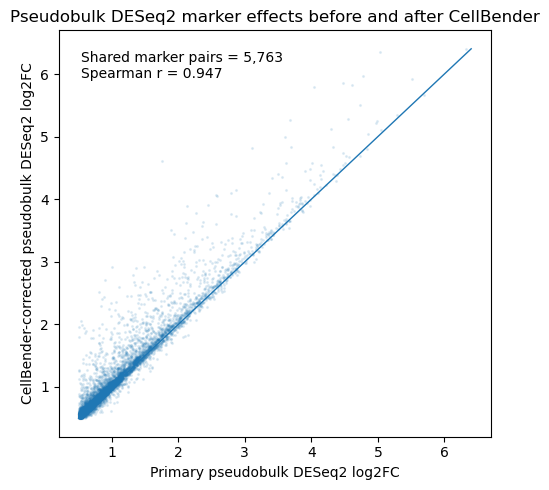

Saved figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB.pdf
Saved summary: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB_summary.csv


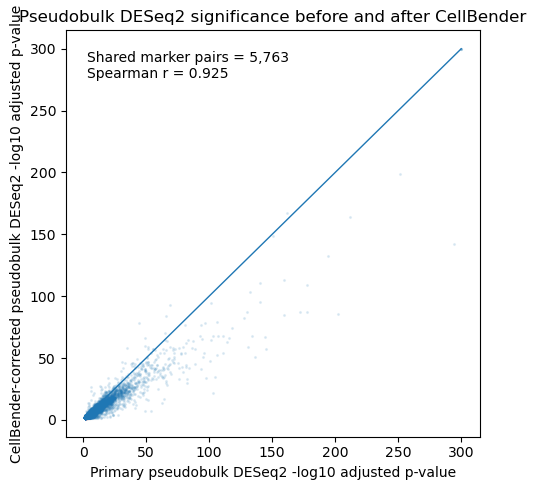

Saved padj figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB_padj.pdf


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Input files
# -----------------------------
primary_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2.csv"
cellbender_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB.csv"

# -----------------------------
# Output files
# -----------------------------
output_fig_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB.pdf"
#output_fig_png = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/DESeq2_log2FC_before_after_CellBender.png"
output_summary_csv = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB_summary.csv"

# -----------------------------
# Read tables
# -----------------------------
primary = pd.read_csv(primary_deseq2_file)
cb = pd.read_csv(cellbender_deseq2_file)

for df in [primary, cb]:
    df["group"] = df["group"].astype(str)
    df["gene"] = df["gene"].astype(str)

# -----------------------------
# Merge matched cluster-gene pairs
# -----------------------------
merged = primary.merge(
    cb,
    on=["group", "gene"],
    suffixes=("_primary", "_CellBender")
)

# -----------------------------
# Summary statistics
# -----------------------------
n_primary = primary[["group", "gene"]].drop_duplicates().shape[0]
n_cb = cb[["group", "gene"]].drop_duplicates().shape[0]
n_shared = merged[["group", "gene"]].drop_duplicates().shape[0]

spearman_r = merged[["log2FoldChange_primary", "log2FoldChange_CellBender"]].corr(
    method="spearman"
).iloc[0, 1]

pearson_r = merged[["log2FoldChange_primary", "log2FoldChange_CellBender"]].corr(
    method="pearson"
).iloc[0, 1]

summary = pd.DataFrame({
    "metric": [
        "primary_DESeq2_marker_pairs",
        "CellBender_DESeq2_marker_pairs",
        "shared_marker_pairs",
        "primary_only_marker_pairs",
        "CellBender_only_marker_pairs",
        "Spearman_log2FC_primary_vs_CellBender",
        "Pearson_log2FC_primary_vs_CellBender"
    ],
    "value": [
        n_primary,
        n_cb,
        n_shared,
        n_primary - n_shared,
        n_cb - n_shared,
        spearman_r,
        pearson_r
    ]
})

summary.to_csv(output_summary_csv, index=False)
print(summary.to_string(index=False))

# -----------------------------
# Plot log2FC before vs after
# -----------------------------
plt.figure(figsize=(5, 5))

plt.scatter(
    merged["log2FoldChange_primary"],
    merged["log2FoldChange_CellBender"],
    s=1.5,
    alpha=0.1
)

min_val = min(
    merged["log2FoldChange_primary"].min(),
    merged["log2FoldChange_CellBender"].min()
)

max_val = max(
    merged["log2FoldChange_primary"].max(),
    merged["log2FoldChange_CellBender"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linewidth=1)

plt.xlabel("Primary pseudobulk DESeq2 log2FC")
plt.ylabel("CellBender-corrected pseudobulk DESeq2 log2FC")
plt.title("Pseudobulk DESeq2 marker effects before and after CellBender")

plt.text(
    0.05,
    0.95,
    f"Shared marker pairs = {n_shared:,}\nSpearman r = {spearman_r:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.savefig(output_fig_pdf, bbox_inches="tight")
#plt.savefig(output_fig_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {output_fig_pdf}")
#print(f"Saved figure: {output_fig_png}")
print(f"Saved summary: {output_summary_csv}")



# -----------------------------
# Plot adjusted p-values before vs after
# Use -log10(padj)
# -----------------------------
output_fig_padj_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB_padj.pdf"

# Avoid padj = 0 issue
eps = 1e-300

merged["neglog10_padj_primary"] = -np.log10(
    merged["padj_primary"].clip(lower=eps)
)

merged["neglog10_padj_CellBender"] = -np.log10(
    merged["padj_CellBender"].clip(lower=eps)
)

spearman_padj = merged[["neglog10_padj_primary", "neglog10_padj_CellBender"]].corr(
    method="spearman"
).iloc[0, 1]

pearson_padj = merged[["neglog10_padj_primary", "neglog10_padj_CellBender"]].corr(
    method="pearson"
).iloc[0, 1]

plt.figure(figsize=(5, 5))

plt.scatter(
    merged["neglog10_padj_primary"],
    merged["neglog10_padj_CellBender"],
    s=1.5,
    alpha=0.1
)

min_val = min(
    merged["neglog10_padj_primary"].min(),
    merged["neglog10_padj_CellBender"].min()
)

max_val = max(
    merged["neglog10_padj_primary"].max(),
    merged["neglog10_padj_CellBender"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linewidth=1)

plt.xlabel("Primary pseudobulk DESeq2 -log10 adjusted p-value")
plt.ylabel("CellBender-corrected pseudobulk DESeq2 -log10 adjusted p-value")
plt.title("Pseudobulk DESeq2 significance before and after CellBender")

plt.text(
    0.05,
    0.95,
    f"Shared marker pairs = {n_shared:,}\nSpearman r = {spearman_padj:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.savefig(output_fig_padj_pdf, bbox_inches="tight")
plt.show()

print(f"Saved padj figure: {output_fig_padj_pdf}")

In [27]:
# -----------------------------
# Per-subgroup marker retention summary
# -----------------------------
primary_pairs = primary[["group", "gene"]].drop_duplicates()
cb_pairs = cb[["group", "gene"]].drop_duplicates()
shared_pairs = primary_pairs.merge(cb_pairs, on=["group", "gene"], how="inner")

primary_by_group = (
    primary_pairs
    .groupby("group")
    .size()
    .rename("primary_DESeq2_markers")
)

cb_by_group = (
    cb_pairs
    .groupby("group")
    .size()
    .rename("CellBender_DESeq2_markers")
)

shared_by_group = (
    shared_pairs
    .groupby("group")
    .size()
    .rename("shared_DESeq2_markers")
)

retention = pd.concat(
    [primary_by_group, cb_by_group, shared_by_group],
    axis=1
).fillna(0)

retention = retention.astype(int).reset_index()

retention["primary_retention_fraction"] = (
    retention["shared_DESeq2_markers"] /
    retention["primary_DESeq2_markers"]
)

retention["jaccard_index"] = (
    retention["shared_DESeq2_markers"] /
    (
        retention["primary_DESeq2_markers"]
        + retention["CellBender_DESeq2_markers"]
        - retention["shared_DESeq2_markers"]
    )
)

retention["primary_only"] = (
    retention["primary_DESeq2_markers"] - retention["shared_DESeq2_markers"]
)

retention["CellBender_only"] = (
    retention["CellBender_DESeq2_markers"] - retention["shared_DESeq2_markers"]
)

output_retention_csv = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DESeq2_marker_retention_before_after_CellBender_by_group.csv"

retention.to_csv(output_retention_csv, index=False)

print(retention.to_string(index=False))
print(f"Saved subgroup retention summary: {output_retention_csv}")

   group  primary_DESeq2_markers  CellBender_DESeq2_markers  shared_DESeq2_markers  primary_retention_fraction  jaccard_index  primary_only  CellBender_only
  GM STR                    2380                       2560                   2106                    0.884874       0.743119           274              454
GM exSTR                    1109                       1126                    911                    0.821461       0.688066           198              215
      WM                    2903                       3361                   2746                    0.945918       0.780557           157              615
Saved subgroup retention summary: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DESeq2_marker_retention_before_after_CellBender_by_group.csv


   group  primary_DESeq2_markers  CellBender_DESeq2_markers  shared_DESeq2_markers  retention_pct  primary_only  CellBender_only
  GM STR                    2380                       2560                   2106      88.487395           274              454
GM exSTR                    1109                       1126                    911      82.146078           198              215
      WM                    2903                       3361                   2746      94.591802           157              615


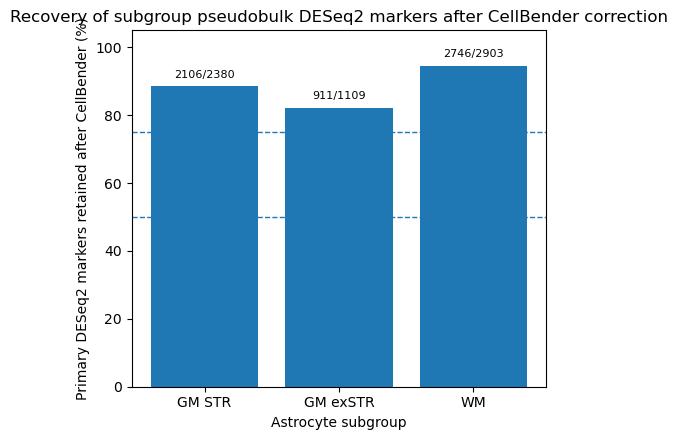

Saved figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DESeq2_marker_retention_fraction_by_group.pdf
Saved figure: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DESeq2_marker_retention_fraction_by_group.png


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

summary_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DESeq2_marker_retention_before_after_CellBender_by_group.csv"

output_fig_pdf = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DESeq2_marker_retention_fraction_by_group.pdf"
output_fig_png = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DESeq2_marker_retention_fraction_by_group.png"

summary = pd.read_csv(summary_file)

numeric_cols = [
    "primary_DESeq2_markers",
    "CellBender_DESeq2_markers",
    "shared_DESeq2_markers",
    "primary_retention_fraction",
    "jaccard_index",
    "primary_only",
    "CellBender_only",
]

for c in numeric_cols:
    if c in summary.columns:
        summary[c] = pd.to_numeric(summary[c], errors="coerce")

# Optional: order subgroups manually
group_order = ["GM STR", "GM exSTR", "WM"]
summary["group"] = pd.Categorical(summary["group"], categories=group_order, ordered=True)
summary = summary.sort_values("group").reset_index(drop=True)

summary["retention_pct"] = (
    summary["shared_DESeq2_markers"]
    / summary["primary_DESeq2_markers"]
    * 100
)

print(summary[[
    "group",
    "primary_DESeq2_markers",
    "CellBender_DESeq2_markers",
    "shared_DESeq2_markers",
    "retention_pct",
    "primary_only",
    "CellBender_only"
]].to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 4.5))

ax.bar(
    summary["group"].astype(str),
    summary["retention_pct"]
)

ax.set_ylabel("Primary DESeq2 markers retained after CellBender (%)")
ax.set_xlabel("Astrocyte subgroup")
ax.set_ylim(0, 105)
ax.set_title("Recovery of subgroup pseudobulk DESeq2 markers after CellBender correction")

ax.axhline(75, linestyle="--", linewidth=1)
ax.axhline(50, linestyle="--", linewidth=1)

for i, row in summary.iterrows():
    ax.text(
        i,
        row["retention_pct"] + 2,
        f'{int(row["shared_DESeq2_markers"])}/{int(row["primary_DESeq2_markers"])}',
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0
    )

plt.tight_layout()
plt.savefig(output_fig_pdf, bbox_inches="tight")
plt.savefig(output_fig_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {output_fig_pdf}")
print(f"Saved figure: {output_fig_png}")

In [29]:
import pandas as pd

# -----------------------------
# Input files
# -----------------------------
primary_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2.csv"
cellbender_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB.csv"

# -----------------------------
# Output file
# -----------------------------
output_table_s1 = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S2_DESeq2_markers_retained_after_CellBender.csv"

# -----------------------------
# Read tables
# -----------------------------
primary = pd.read_csv(primary_deseq2_file)
cb = pd.read_csv(cellbender_deseq2_file)

for df in [primary, cb]:
    df["group"] = df["group"].astype(str) #subGroup: GM STR, GM exSTR, WM
    df["gene"] = df["gene"].astype(str)

# -----------------------------
# Keep CellBender columns to append
# -----------------------------
cb_cols_to_add = [
    "group",
    "gene",
    "baseMean",
    "log2FoldChange",
    "lfcSE",
    "stat",
    "pvalue",
    "padj"
]

# Only keep columns that actually exist
cb_cols_to_add = [c for c in cb_cols_to_add if c in cb.columns]

cb_add = cb[cb_cols_to_add].copy()

# Rename CellBender statistics
rename_cb = {
    "baseMean": "CellBender_baseMean",
    "log2FoldChange": "CellBender_log2FoldChange",
    "lfcSE": "CellBender_lfcSE",
    "stat": "CellBender_stat",
    "pvalue": "CellBender_pvalue",
    "padj": "CellBender_padj"
}

cb_add = cb_add.rename(columns=rename_cb)

# -----------------------------
# Merge: primary table as main body
# -----------------------------
table_s1 = primary.merge(
    cb_add,
    on=["group", "gene"],
    how="inner"
)

# -----------------------------
# Optional: rename primary DESeq2 columns for clarity
# -----------------------------
rename_primary = {
    "baseMean": "primary_baseMean",
    "log2FoldChange": "primary_log2FoldChange",
    "lfcSE": "primary_lfcSE",
    "stat": "primary_stat",
    "pvalue": "primary_pvalue",
    "padj": "primary_padj"
}

table_s1 = table_s1.rename(columns=rename_primary)

# -----------------------------
# Optional: add effect-size change columns
# -----------------------------
if {"primary_log2FoldChange", "CellBender_log2FoldChange"}.issubset(table_s1.columns):
    table_s1["delta_log2FoldChange_CellBender_minus_primary"] = (
        table_s1["CellBender_log2FoldChange"] - table_s1["primary_log2FoldChange"]
    )
    table_s1["abs_delta_log2FoldChange"] = table_s1[
        "delta_log2FoldChange_CellBender_minus_primary"
    ].abs()

    table_s1["same_log2FC_direction"] = (
        table_s1["primary_log2FoldChange"] * table_s1["CellBender_log2FoldChange"] > 0
    )

# -----------------------------
# Optional: sort for readability
# -----------------------------
sort_cols = [c for c in ["group", "primary_padj", "gene"] if c in table_s1.columns]
table_s1 = table_s1.sort_values(sort_cols)

# -----------------------------
# Save
# -----------------------------
table_s1.to_csv(output_table_s1, index=False)

print("Saved:", output_table_s1)
print("Rows in Table S1:", table_s1.shape[0])
print("Columns in Table S1:", table_s1.shape[1])

if "same_log2FC_direction" in table_s1.columns:
    print("Same direction:", table_s1["same_log2FC_direction"].sum())
    print("Different direction:", (~table_s1["same_log2FC_direction"]).sum())

table_s1.head()

Saved: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S2_DESeq2_markers_retained_after_CellBender.csv
Rows in Table S1: 5763
Columns in Table S1: 18
Same direction: 5763
Different direction: 0


,primary_baseMean,primary_log2FoldChange,primary_lfcSE,primary_stat,primary_pvalue,primary_padj,group,gene,n_donors_used,CellBender_baseMean,CellBender_log2FoldChange,CellBender_lfcSE,CellBender_stat,CellBender_pvalue,CellBender_padj,delta_log2FoldChange_CellBender_minus_primary,abs_delta_log2FoldChange,same_log2FC_direction
259,4964.732119,2.320110,0.056802,40.845670,0.000000e+00,0.000000e+00,GM STR,AC073050.1,9,4434.248919,2.654769,0.066246,40.074512,0.000000e+00,0.000000e+00,0.334659,0.334659,True
863,5852.668404,4.552603,0.058810,77.412633,0.000000e+00,0.000000e+00,GM STR,GRM3,9,5430.074201,5.276837,0.110776,47.635056,0.000000e+00,0.000000e+00,0.724234,0.724234,True
1359,1037.789648,3.860474,0.080202,48.134343,0.000000e+00,0.000000e+00,GM STR,OAF,9,1029.602611,3.831699,0.102684,37.315558,9.180723e-305,6.095311e-301,-0.028775,0.028775,True
1427,2318.185734,6.325899,0.126660,49.944025,0.000000e+00,0.000000e+00,GM STR,WIF1,9,2243.738673,6.402701,0.162692,39.354812,0.000000e+00,0.000000e+00,0.076802,0.076802,True
1464,2630.935735,5.507267,0.149110,36.934221,1.305205e-298,4.752064e-295,GM STR,TMEM132C,9,2557.268277,5.926961,0.230201,25.746870,3.494379e-146,9.280022e-143,0.419694,0.419694,True


In [16]:
import pandas as pd
import numpy as np

# -----------------------------
# Input files
# -----------------------------
primary_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2.csv"

cellbender_deseq2_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Subgroup_DEGs_pseudobulk-DESeq2-afterCB_all_genes.csv"

# -----------------------------
# Output file
# -----------------------------
output_table_s2 = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S2_DESeq2_markers_withCellBenderInfo.csv"

# -----------------------------
# Thresholds
# -----------------------------
padj_thr = 0.05
lfc_thr = 0.5

# -----------------------------
# Read tables
# -----------------------------
primary = pd.read_csv(primary_deseq2_file)
cb = pd.read_csv(cellbender_deseq2_file)

for df in [primary, cb]:
    df["group"] = df["group"].astype(str)
    df["gene"] = df["gene"].astype(str)

# -----------------------------
# Keep CellBender all-gene statistics
# -----------------------------
cb_cols_to_add = [
    "group",
    "gene",
    "baseMean",
    "log2FoldChange",
    "lfcSE",
    "stat",
    "pvalue",
    "padj"
]

cb_cols_to_add = [c for c in cb_cols_to_add if c in cb.columns]
cb_add = cb[cb_cols_to_add].copy()

cb_add = cb_add.rename(columns={
    "baseMean": "CellBender_baseMean",
    "log2FoldChange": "CellBender_log2FoldChange",
    "lfcSE": "CellBender_lfcSE",
    "stat": "CellBender_stat",
    "pvalue": "CellBender_pvalue",
    "padj": "CellBender_padj"
})

# -----------------------------
# Merge: keep ALL primary markers
# -----------------------------
table_s2 = primary.merge(
    cb_add,
    on=["group", "gene"],
    how="left"
)

# -----------------------------
# Rename primary columns
# -----------------------------
table_s2 = table_s2.rename(columns={
    "baseMean": "primary_baseMean",
    "log2FoldChange": "primary_log2FoldChange",
    "lfcSE": "primary_lfcSE",
    "stat": "primary_stat",
    "pvalue": "primary_pvalue",
    "padj": "primary_padj"
})

# -----------------------------
# CellBender support status
# -----------------------------
has_cb_result = table_s2["CellBender_padj"].notna()

table_s2["tested_after_CellBender"] = has_cb_result

table_s2["retained_after_CellBender"] = (
    has_cb_result
    & (table_s2["CellBender_padj"] < padj_thr)
    & (table_s2["CellBender_log2FoldChange"] > lfc_thr)
)

table_s2["retained_after_CellBender"] = table_s2[
    "retained_after_CellBender"
].map({True: "yes", False: "no"})

# -----------------------------
# Effect-size and significance changes
# -----------------------------
table_s2["delta_log2FoldChange_CellBender_minus_primary"] = (
    table_s2["CellBender_log2FoldChange"]
    - table_s2["primary_log2FoldChange"]
)

table_s2["abs_delta_log2FoldChange"] = table_s2[
    "delta_log2FoldChange_CellBender_minus_primary"
].abs()

table_s2["same_log2FC_direction"] = (
    table_s2["primary_log2FoldChange"]
    * table_s2["CellBender_log2FoldChange"] > 0
)

table_s2["primary_minuslog10_padj"] = -np.log10(
    table_s2["primary_padj"].clip(lower=1e-300)
)

table_s2["CellBender_minuslog10_padj"] = -np.log10(
    table_s2["CellBender_padj"].clip(lower=1e-300)
)

table_s2["delta_minuslog10_padj"] = (
    table_s2["CellBender_minuslog10_padj"]
    - table_s2["primary_minuslog10_padj"]
)

# -----------------------------
# Sort and save
# -----------------------------
sort_cols = [c for c in ["group", "primary_padj", "gene"] if c in table_s2.columns]
table_s2 = table_s2.sort_values(sort_cols)

table_s2.to_csv(output_table_s2, index=False)

print("Saved:", output_table_s2)
print("Primary marker rows:", primary.shape[0])
print("Rows in Table S2:", table_s2.shape[0])
print("Columns in Table S2:", table_s2.shape[1])

print("\nTested after CellBender:")
print(table_s2["tested_after_CellBender"].value_counts(dropna=False))

print("\nRetained after CellBender:")
print(table_s2["retained_after_CellBender"].value_counts(dropna=False))

print("\nSame log2FC direction:")
print(table_s2["same_log2FC_direction"].value_counts(dropna=False))

table_s2.head()

Saved: /home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S2_DESeq2_markers_withCellBenderInfo.csv
Primary marker rows: 6392
Rows in Table S2: 6392
Columns in Table S2: 23

Tested after CellBender:
tested_after_CellBender
True     6350
False      42
Name: count, dtype: int64

Retained after CellBender:
retained_after_CellBender
yes    5763
no      629
Name: count, dtype: int64

Same log2FC direction:
same_log2FC_direction
True     6334
False      58
Name: count, dtype: int64


,primary_baseMean,primary_log2FoldChange,primary_lfcSE,primary_stat,primary_pvalue,primary_padj,group,gene,n_donors_used,CellBender_baseMean,...,CellBender_pvalue,CellBender_padj,tested_after_CellBender,retained_after_CellBender,delta_log2FoldChange_CellBender_minus_primary,abs_delta_log2FoldChange,same_log2FC_direction,primary_minuslog10_padj,CellBender_minuslog10_padj,delta_minuslog10_padj
291,4964.732119,2.320110,0.056802,40.845670,0.000000e+00,0.000000e+00,GM STR,AC073050.1,9,4434.248919,...,0.000000e+00,0.000000e+00,True,yes,0.334659,0.334659,True,300.000000,300.000000,0.000000
958,5852.668404,4.552603,0.058810,77.412633,0.000000e+00,0.000000e+00,GM STR,GRM3,9,5430.074201,...,0.000000e+00,0.000000e+00,True,yes,0.724234,0.724234,True,300.000000,300.000000,0.000000
1503,1037.789648,3.860474,0.080202,48.134343,0.000000e+00,0.000000e+00,GM STR,OAF,9,1029.602611,...,9.180723e-305,6.095311e-301,True,yes,-0.028775,0.028775,True,300.000000,300.000000,0.000000
1579,2318.185734,6.325899,0.126660,49.944025,0.000000e+00,0.000000e+00,GM STR,WIF1,9,2243.738673,...,0.000000e+00,0.000000e+00,True,yes,0.076802,0.076802,True,300.000000,300.000000,0.000000
1621,2630.935735,5.507267,0.149110,36.934221,1.305205e-298,4.752064e-295,GM STR,TMEM132C,9,2557.268277,...,3.494379e-146,9.280022e-143,True,yes,0.419694,0.419694,True,294.323118,142.032451,-152.290667
